# Comparaison d'architectures pour la classification de plats (Food-101)
## Projet Deep Learning - du MLP au Vision Transformer

> *Application visée : une app nutritionnelle qui identifie un plat à partir d'une photo pour estimer ses calories. On cherche le meilleur compromis précision / coût de calcul, d'où la comparaison de plusieurs architectures.*

---

### Plan du projet

| # | Exigence | Section |
|---|----------|---------|
| 1 | Choisir une data (+ référence) | Partie 1 - Food-101 |
| 2 | Modifier la dimension & le nombre de classes | Partie 2 - resize 128x128 + 10 classes |
| 3 | Modèle simple (dense) | Partie 4 - MLP baseline |
| 4 | CNN (comparer >= 2 cas) | Partie 5 - CNN A vs CNN B |
| 5 | ResNet (différent du TP) | Partie 6 - Mini-ResNet *from scratch* |
| 6 | Transfer learning (Hugging Face) | Partie 7 - ViT pré-entraîné |
| + | Early stopping, régularisation, elastic net | Dans tous les modèles |

### Environnement
Keras 3 avec backend PyTorch (pas de TensorFlow). L'API Keras (Sequential, compile, fit, callbacks) reste la même, c'est juste le moteur de calcul qui change.

### Dataset & référence
Food-101 - 101 classes, 101 000 images (750 train + 250 test par classe).

> Bossard, L., Guillaumin, M., & Van Gool, L. (2014). *Food-101 - Mining Discriminative Components with Random Forests.* European Conference on Computer Vision (ECCV).
>
> https://huggingface.co/datasets/ethz/food101

## 0. Imports & configuration

Les bibliothèques utilisées : torch, keras 3, transformers, datasets, scikit-learn, matplotlib, seaborn. La cellule suivante (commentée) sert à les installer si besoin.

In [ ]:
# Installation des dependances si besoin (decommenter la ligne) :
# %pip install torch keras transformers datasets scikit-learn matplotlib seaborn

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # backend torch (pas de TF), a definir avant keras
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# on masque les warnings (widgets tqdm, HF Hub non authentifie, etc.)
import warnings, logging
warnings.filterwarnings("ignore")
for _name in ("datasets", "huggingface_hub", "transformers"):
    logging.getLogger(_name).setLevel(logging.ERROR)

# sous Windows il faut importer datasets avant torch, sinon conflit de DLL OpenMP
# (torch et pyarrow ont chacun leur libiomp5md.dll) et le kernel crashe
from datasets import load_dataset

import numpy as np
import matplotlib.pyplot as plt
import torch
import keras
from keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import L1L2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# reproductibilite
SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Keras", keras.__version__, "| backend:", keras.backend.backend(), "| device:", DEVICE)

Keras 3.15.0 | backend: torch | device: cuda


## Partie 1 - Chargement de Food-101 (Hugging Face) & sélection des classes

Je ne garde que 10 classes, dont plusieurs assez proches visuellement (mes "pièges") pour rendre la tâche plus difficile et avoir une matrice de confusion intéressante :
- `spaghetti_bolognese` vs `spaghetti_carbonara` (deux plats de pâtes)
- `cheesecake` vs `chocolate_cake` (deux gâteaux)
- + `pizza`, `hamburger`, `french_fries`, `sushi`, `ramen`, `steak`

Le premier appel télécharge Food-101 (~5 Go) dans le cache Hugging Face ; ensuite c'est lu directement depuis le cache.

In [3]:
from datasets import load_dataset

# 10 classes retenues (toutes presentes dans Food-101)
SELECTED = [
    'spaghetti_bolognese', 'spaghetti_carbonara',  # pates (pieges)
    'cheesecake', 'chocolate_cake',                # gateaux (pieges)
    'pizza', 'hamburger', 'french_fries',
    'sushi', 'ramen', 'steak',
]
NUM_CLASSES = len(SELECTED)

# NB : avec datasets >= 3, le nom canonique est "ethz/food101" (et non "food101")
# Splits HF : 'train' (75 750) et 'validation' (25 250 = test officiel)
food = load_dataset("ethz/food101")
all_names = food['train'].features['label'].names

sel_ids = [all_names.index(c) for c in SELECTED]          # indices dans les 101 classes
id2new  = {old: new for new, old in enumerate(sel_ids)}   # remapping vers 0..9
print("Classes :", SELECTED)
print("IDs originaux :", sel_ids)

Classes : ['spaghetti_bolognese', 'spaghetti_carbonara', 'cheesecake', 'chocolate_cake', 'pizza', 'hamburger', 'french_fries', 'sushi', 'ramen', 'steak']
IDs originaux : [90, 91, 16, 21, 76, 53, 40, 95, 81, 93]


## Partie 2 - Modification de la dimension et du nombre de classes

Les deux transformations demandées par le sujet :
1. Nombre de classes : 101 -> 10 (sous-ensemble, labels ré-indexés de 0 à 9).
2. Dimension : images redimensionnées en 128x128x3 pour les modèles from scratch. Le ViT (Partie 7) utilise du 224x224.

J'échantillonne `MAX_TRAIN_PER_CLASS` / `MAX_TEST_PER_CLASS` images par classe ; avec 750 / 250 on prendrait tout le dataset.

In [4]:
from PIL import Image

IMG_SIZE = 128                 # dimension cible (point 2 du sujet)
MAX_TRAIN_PER_CLASS = 150      # CPU : 150 | GPU/Colab : 750
MAX_TEST_PER_CLASS  = 50       # CPU :  50 | GPU/Colab : 250

def pick_indices(split, max_per_class):
    # Selectionne (sans decoder les images) les indices des classes voulues, plafonnes par classe
    labels = np.array(split['label'])
    idx = []
    for old in sel_ids:
        found = np.where(labels == old)[0][:max_per_class]
        idx.extend(found.tolist())
    return idx

def to_arrays(split, indices, size):
    # Decode + redimensionne uniquement les images selectionnees -> tableaux numpy uint8
    subset = split.select(indices)
    X = np.zeros((len(subset), size, size, 3), dtype='uint8')
    y = np.zeros(len(subset), dtype='int64')
    for i, ex in enumerate(subset):
        img = ex['image'].convert('RGB').resize((size, size), Image.BILINEAR)
        X[i] = np.asarray(img)
        y[i] = id2new[ex['label']]
    return X, y

train_idx = pick_indices(food['train'],      MAX_TRAIN_PER_CLASS)
test_idx  = pick_indices(food['validation'], MAX_TEST_PER_CLASS)

X_trainval, y_trainval = to_arrays(food['train'],      train_idx, IMG_SIZE)
X_test,     y_test     = to_arrays(food['validation'], test_idx,  IMG_SIZE)

# Split train / validation (pour l'early stopping), stratifie
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=SEED)

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)
print("Dimension d'une image :", X_train.shape[1:], "| Nb classes :", NUM_CLASSES)

Train : (1275, 128, 128, 3) | Val : (225, 128, 128, 3) | Test : (500, 128, 128, 3)
Dimension d'une image : (128, 128, 3) | Nb classes : 10


## Partie 3 - Exploration des données (EDA)

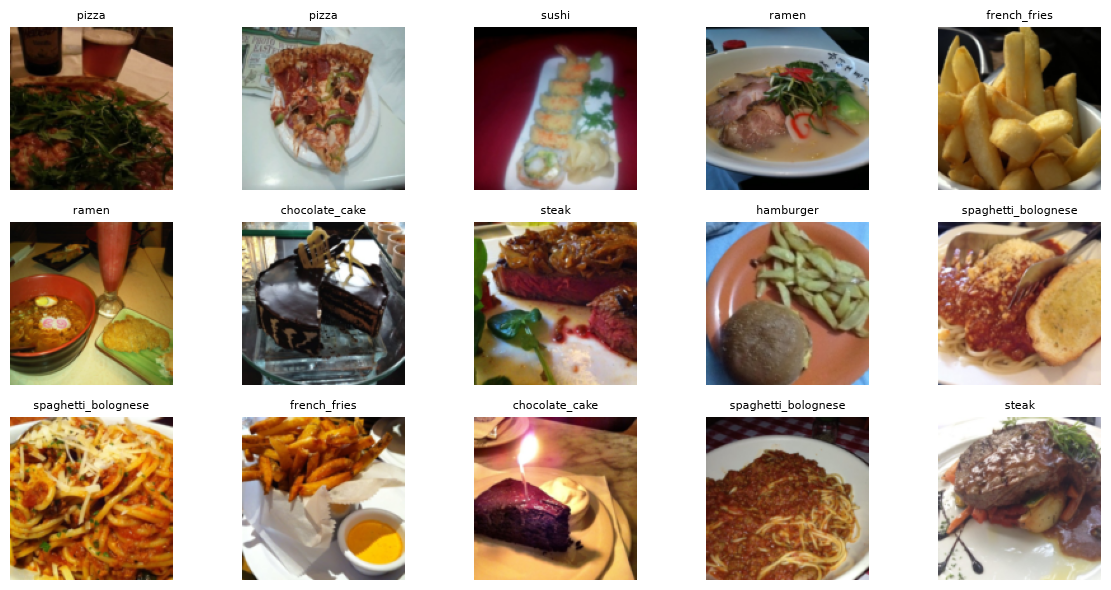

In [5]:
plt.figure(figsize=(12, 6))
for i in range(15):
    j = np.random.randint(len(X_train))
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[j])
    plt.title(SELECTED[y_train[j]], fontsize=8)
    plt.axis('off')
plt.tight_layout(); plt.show()

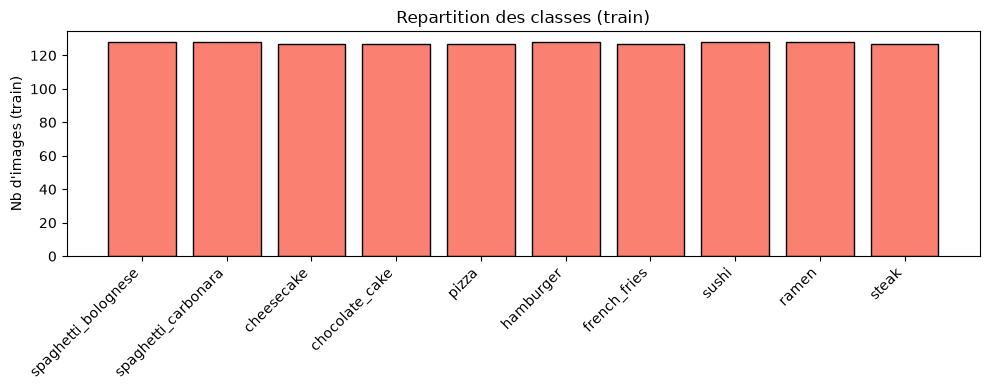

In [6]:
counts = np.bincount(y_train, minlength=NUM_CLASSES)
plt.figure(figsize=(10, 4))
plt.bar(SELECTED, counts, color='salmon', edgecolor='k')
plt.xticks(rotation=45, ha='right'); plt.ylabel("Nb d'images (train)")
plt.title("Repartition des classes (train)"); plt.tight_layout(); plt.show()

## Outils communs : augmentation, régularisation & callbacks

Rescaling 1/255, data augmentation (flip / rotation / zoom), callbacks (EarlyStopping + ReduceLROnPlateau), elastic net (L1+L2) et une fonction pour tracer les courbes.

L'early stopping surveille `val_accuracy` et pas `val_loss` : avec la BatchNorm la val_loss remonte dès le début, donc en suivant la loss on garderait un modèle pas entraîné.

In [7]:
BATCH = 64
EPOCHS = 40

ELASTIC_NET = L1L2(l1=1e-5, l2=1e-4)   # elastic net = L1 + L2

def make_augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
    ], name="augmentation")

def get_callbacks(patience=15):
    # je surveille val_accuracy, pas val_loss : avec la BatchNorm la val_loss
    # remonte des le debut, donc restore_best_weights garderait un modele non entraine
    return [
        EarlyStopping(monitor='val_accuracy', mode='max', patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ]

def plot_history(history, title=""):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['accuracy'], label='train'); ax[0].plot(h['val_accuracy'], label='val')
    ax[0].set_title(f'Accuracy {title}'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(h['loss'], label='train'); ax[1].plot(h['val_loss'], label='val')
    ax[1].set_title(f'Loss {title}'); ax[1].set_xlabel('epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

def test_accuracy(model, X, y):
    return float(model.evaluate(X, y, verbose=0)[1])

results = {}

## Partie 4 - Modèle 1 : réseau dense (MLP), baseline

Un MLP tout simple qui aplatit l'image. C'est ma référence : comme il ignore la structure spatiale, je m'attends à un score faible.

Régularisation : Dropout + elastic net (sur la 2e couche) + early stopping. Je ne mets pas l'elastic net sur la 1re couche (beaucoup trop de poids, ça bloque l'apprentissage), je la stabilise plutôt avec une BatchNorm.

Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,302,282 (96.52 MB)

 Trainable params: 25,301,258 (96.52 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/60
20/20 - 2s - 104ms/step - accuracy: 0.1678 - loss: 2.5991 - val_accuracy: 0.1200 - val_loss: 8.4478 - learning_rate: 0.0010
Epoch 2/60
20/20 - 1s - 42ms/step - accuracy: 0.2816 - loss: 2.1383 - val_accuracy: 0.1200 - val_loss: 4.6625 - learning_rate: 0.0010
Epoch 3/60
20/20 - 1s - 47ms/step - accuracy: 0.3318 - loss: 1.9884 - val_accuracy: 0.1244 - val_loss: 4.1549 - learning_rate: 0.0010
Epoch 4/60
20/20 - 1s - 48ms/step - accuracy: 0.3616 - loss: 1.9065 - val_accuracy: 0.1556 - val_loss: 3.2003 - learning_rate: 0.0010
Epoch 5/60
20/20 - 1s - 47ms/step - accuracy: 0.4039 - loss: 1.7950 - val_accuracy: 0.1867 - val_loss: 2.5917 - learning_rate: 0.0010
Epoch 6/60
20/20 - 1s - 46ms/step - accuracy: 0.4510 - loss: 1.6831 - val_accuracy: 0.2089 - val_loss: 2.5881 - learning_rate: 0.0010
Epoch 7/60
20/20 - 1s - 47ms/step - accuracy: 0.5067 - loss: 1.5360 - val_accuracy: 0.2578 - val_loss: 2.2504 - learning_rate: 0.0010
Epoch 8/60
20/20 - 1s - 36ms/step - accuracy: 0.5655 - loss: 

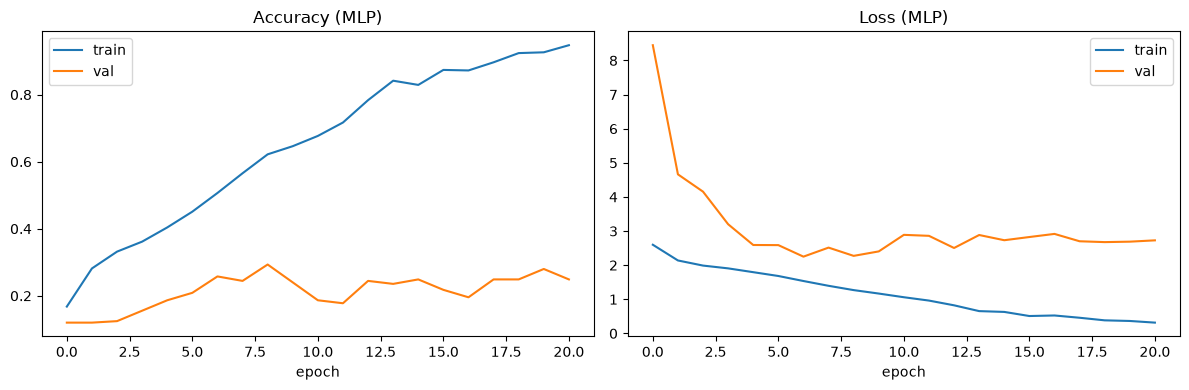

Test accuracy MLP : 0.294


In [8]:
def build_mlp():
    # pas d'elastic net sur la 1re couche : 49152x512 ~ 25M poids, la penalite explose
    # et le modele n'apprend plus. BatchNorm a la place, elastic net garde sur la 2e couche.
    model = keras.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1.0 / 255),
        layers.Flatten(),
        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=ELASTIC_NET),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="MLP_baseline")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

mlp = build_mlp()
mlp.summary()
hist_mlp = mlp.fit(X_train, y_train, validation_data=(X_val, y_val),
                   batch_size=BATCH, epochs=60, callbacks=get_callbacks(patience=12), verbose=2)
plot_history(hist_mlp, "(MLP)")
results['1. MLP (dense)'] = test_accuracy(mlp, X_test, y_test)
print("Test accuracy MLP :", round(results['1. MLP (dense)'], 4))

## Partie 5 - Modèle 2 : CNN (comparaison de 2 cas)

| | CNN A - basique | CNN B - régularisé |
|---|---|---|
| Data augmentation | non | oui |
| BatchNorm | non | oui |
| Dropout | non | oui |
| Elastic Net (L1+L2) | non | oui |

Mon hypothèse : le CNN A va sur-apprendre (gros écart train/val) et le CNN B devrait mieux généraliser.

Epoch 1/40
20/20 - 2s - 80ms/step - accuracy: 0.1255 - loss: 2.4141 - val_accuracy: 0.1689 - val_loss: 2.2781 - learning_rate: 0.0010
Epoch 2/40
20/20 - 1s - 51ms/step - accuracy: 0.1890 - loss: 2.2216 - val_accuracy: 0.1956 - val_loss: 2.1864 - learning_rate: 0.0010
Epoch 3/40
20/20 - 1s - 52ms/step - accuracy: 0.2784 - loss: 2.0245 - val_accuracy: 0.2622 - val_loss: 2.0017 - learning_rate: 0.0010
Epoch 4/40
20/20 - 1s - 47ms/step - accuracy: 0.3780 - loss: 1.7904 - val_accuracy: 0.2844 - val_loss: 1.9256 - learning_rate: 0.0010
Epoch 5/40
20/20 - 1s - 50ms/step - accuracy: 0.4314 - loss: 1.6072 - val_accuracy: 0.3111 - val_loss: 1.9676 - learning_rate: 0.0010
Epoch 6/40
20/20 - 1s - 49ms/step - accuracy: 0.5271 - loss: 1.4084 - val_accuracy: 0.3378 - val_loss: 1.9616 - learning_rate: 0.0010
Epoch 7/40
20/20 - 1s - 49ms/step - accuracy: 0.6220 - loss: 1.1412 - val_accuracy: 0.3333 - val_loss: 2.0143 - learning_rate: 0.0010
Epoch 8/40
20/20 - 1s - 48ms/step - accuracy: 0.6973 - loss: 0

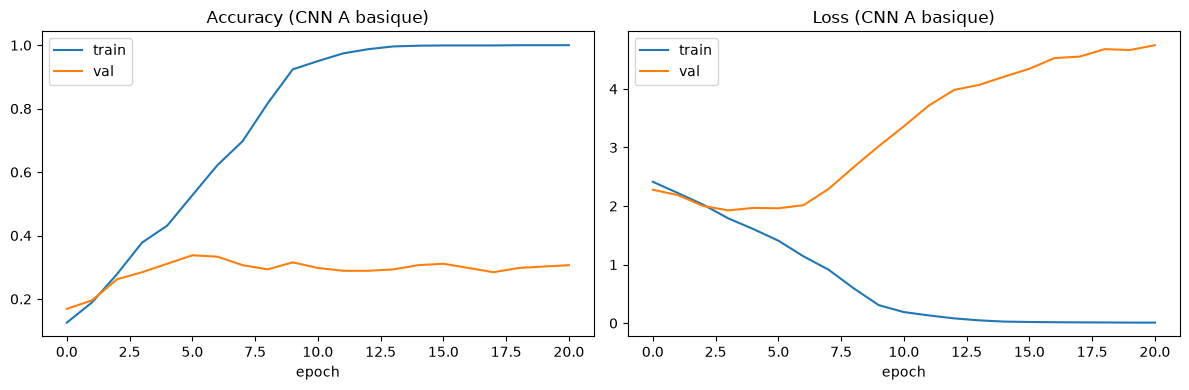

Test accuracy CNN A : 0.356


In [9]:
# --- CNN A : basique, SANS regularisation ---
def build_cnn_basic():
    model = keras.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'), layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="CNN_A_basique")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_a = build_cnn_basic()
hist_a = cnn_a.fit(X_train, y_train, validation_data=(X_val, y_val),
                   batch_size=BATCH, epochs=EPOCHS, callbacks=get_callbacks(), verbose=2)
plot_history(hist_a, "(CNN A basique)")
results['2a. CNN basique'] = test_accuracy(cnn_a, X_test, y_test)
print("Test accuracy CNN A :", round(results['2a. CNN basique'], 4))

Epoch 1/80
20/20 - 13s - 674ms/step - accuracy: 0.1835 - loss: 2.3363 - val_accuracy: 0.1511 - val_loss: 2.3703 - learning_rate: 0.0010
Epoch 2/80
20/20 - 13s - 658ms/step - accuracy: 0.2220 - loss: 2.2175 - val_accuracy: 0.1200 - val_loss: 2.3713 - learning_rate: 0.0010
Epoch 3/80
20/20 - 13s - 638ms/step - accuracy: 0.2667 - loss: 2.1008 - val_accuracy: 0.0978 - val_loss: 2.3961 - learning_rate: 0.0010
Epoch 4/80
20/20 - 14s - 686ms/step - accuracy: 0.3145 - loss: 2.0498 - val_accuracy: 0.0978 - val_loss: 2.4947 - learning_rate: 0.0010
Epoch 5/80
20/20 - 13s - 658ms/step - accuracy: 0.3169 - loss: 2.0120 - val_accuracy: 0.0978 - val_loss: 2.5791 - learning_rate: 0.0010
Epoch 6/80
20/20 - 13s - 647ms/step - accuracy: 0.3082 - loss: 2.0055 - val_accuracy: 0.0978 - val_loss: 2.7227 - learning_rate: 0.0010
Epoch 7/80
20/20 - 13s - 653ms/step - accuracy: 0.3561 - loss: 1.9444 - val_accuracy: 0.0978 - val_loss: 2.7683 - learning_rate: 5.0000e-04
Epoch 8/80
20/20 - 13s - 656ms/step - accura

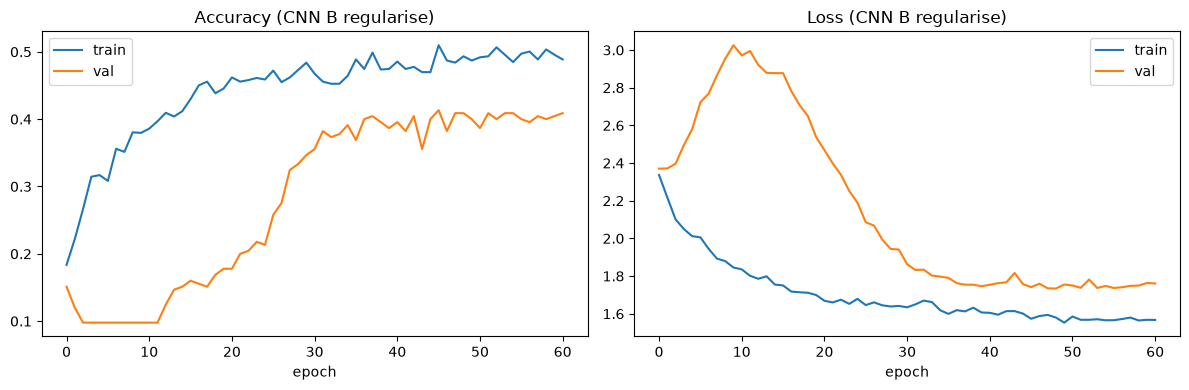

Test accuracy CNN B : 0.458


In [10]:
# --- CNN B : regularise (augmentation + BatchNorm + Dropout + Elastic Net) ---
def build_cnn_reg():
    model = keras.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1.0 / 255),
        make_augmentation(),
        layers.Conv2D(32, 3, padding='same', kernel_regularizer=ELASTIC_NET),
        layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', kernel_regularizer=ELASTIC_NET),
        layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', kernel_regularizer=ELASTIC_NET),
        layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=ELASTIC_NET),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name="CNN_B_regularise")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_b = build_cnn_reg()
# augmentation + BatchNorm => convergence lente : la val_accuracy reste au hasard
# une dizaine d'epochs avant de monter, donc patience elevee et beaucoup d'epochs
hist_b = cnn_b.fit(X_train, y_train, validation_data=(X_val, y_val),
                   batch_size=BATCH, epochs=80, callbacks=get_callbacks(patience=15), verbose=2)
plot_history(hist_b, "(CNN B regularise)")
results['2b. CNN regularise'] = test_accuracy(cnn_b, X_test, y_test)
print("Test accuracy CNN B :", round(results['2b. CNN regularise'], 4))

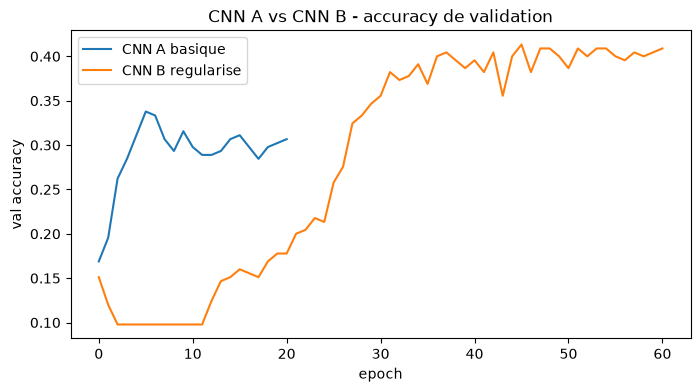

In [11]:
# Comparaison directe des deux CNN (val accuracy)
plt.figure(figsize=(8, 4))
plt.plot(hist_a.history['val_accuracy'], label='CNN A basique')
plt.plot(hist_b.history['val_accuracy'], label='CNN B regularise')
plt.title("CNN A vs CNN B - accuracy de validation")
plt.xlabel('epoch'); plt.ylabel('val accuracy'); plt.legend(); plt.show()

## Partie 6 - Modèle 3 : ResNet from scratch (différent du TP)

Un mini-ResNet construit avec l'API fonctionnelle de Keras, avec de vrais blocs résiduels (skip connections : `sortie = F(x) + x`). C'est ce qui permet d'entraîner des réseaux profonds sans vanishing gradient.

> Référence : He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition.* CVPR.

Model: "Mini_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 128, 128,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 128, 128,  │          0 │ rescaling_3[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │        896 │ augmentation[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_4[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_5[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     18,496 │ activation_6[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_7[0][

 Total params: 606,858 (2.31 MB)

 Trainable params: 605,002 (2.31 MB)

 Non-trainable params: 1,856 (7.25 KB)

Epoch 1/100
20/20 - 15s - 751ms/step - accuracy: 0.1741 - loss: 2.8420 - val_accuracy: 0.0978 - val_loss: 2.6410 - learning_rate: 0.0010
Epoch 2/100
20/20 - 16s - 776ms/step - accuracy: 0.2180 - loss: 2.5244 - val_accuracy: 0.0933 - val_loss: 2.6043 - learning_rate: 0.0010
Epoch 3/100
20/20 - 15s - 771ms/step - accuracy: 0.2463 - loss: 2.3754 - val_accuracy: 0.0978 - val_loss: 2.8661 - learning_rate: 0.0010
Epoch 4/100
20/20 - 16s - 776ms/step - accuracy: 0.2651 - loss: 2.3149 - val_accuracy: 0.0978 - val_loss: 3.1928 - learning_rate: 0.0010
Epoch 5/100
20/20 - 15s - 771ms/step - accuracy: 0.2855 - loss: 2.2298 - val_accuracy: 0.0978 - val_loss: 3.2925 - learning_rate: 0.0010
Epoch 6/100
20/20 - 15s - 762ms/step - accuracy: 0.3098 - loss: 2.1916 - val_accuracy: 0.0978 - val_loss: 3.3928 - learning_rate: 0.0010
Epoch 7/100
20/20 - 16s - 776ms/step - accuracy: 0.3051 - loss: 2.1729 - val_accuracy: 0.1111 - val_loss: 3.1541 - learning_rate: 0.0010
Epoch 8/100
20/20 - 15s - 759ms/step - ac

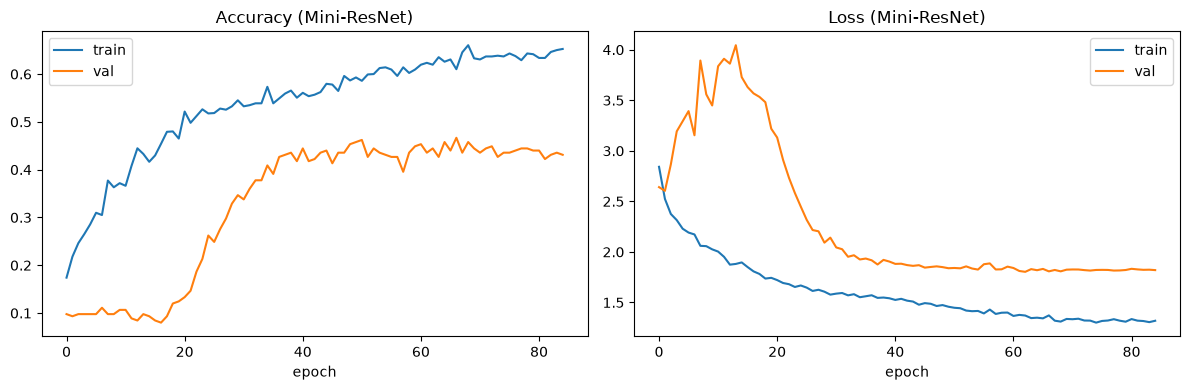

Test accuracy ResNet : 0.534


In [12]:
def residual_block(x, filters, downsample=False):
    # bloc residuel : 2 convs + skip connection (sortie = F(x) + x)
    shortcut = x
    stride = 2 if downsample else 1
    y = layers.Conv2D(filters, 3, strides=stride, padding='same', kernel_regularizer=ELASTIC_NET)(x)
    y = layers.BatchNormalization()(y); y = layers.Activation('relu')(y)
    y = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=ELASTIC_NET)(y)
    y = layers.BatchNormalization()(y)
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    out = layers.Add()([y, shortcut])
    return layers.Activation('relu')(out)

def build_resnet():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))
    x = layers.Rescaling(1.0 / 255)(inp)
    x = make_augmentation()(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = residual_block(x, 32)
    x = residual_block(x, 64,  downsample=True)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inp, out, name="Mini_ResNet")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

resnet = build_resnet()
resnet.summary()
# comme le CNN B (BatchNorm partout), il lui faut beaucoup d'epochs pour decoller
hist_res = resnet.fit(X_train, y_train, validation_data=(X_val, y_val),
                      batch_size=BATCH, epochs=100, callbacks=get_callbacks(patience=18), verbose=2)
plot_history(hist_res, "(Mini-ResNet)")
results['3. ResNet (scratch)'] = test_accuracy(resnet, X_test, y_test)
print("Test accuracy ResNet :", round(results['3. ResNet (scratch)'], 4))

## Partie 7 - Modèle 4 : Transfer learning avec Hugging Face (ViT)

J'utilise un Vision Transformer (ViT) pré-entraîné sur ImageNet-21k (`google/vit-base-patch16-224-in21k`) comme extracteur de features :
1. chaque image (224x224) passe dans le ViT gelé (PyTorch, `torch.no_grad`) -> un vecteur de 768 features (`pooler_output`) ;
2. j'entraîne une petite tête dense (Keras) sur ces features, avec elastic net + early stopping.

Cette approche (feature extraction) est rapide et évite de ré-entraîner les 86M de paramètres du ViT. Le modèle pré-entraîné (~330 Mo) se télécharge au premier appel.

In [13]:
from PIL import Image
from transformers import ViTModel

VIT_NAME = "google/vit-base-patch16-224-in21k"
vit = ViTModel.from_pretrained(VIT_NAME).to(DEVICE).eval()

# Pretraitement ViT fait a la main (evite la dependance torchvision) :
# resize 224, mise a l'echelle [0,1], normalisation (x - 0.5) / 0.5, passage en NCHW
VIT_SIZE, VIT_MEAN, VIT_STD = 224, 0.5, 0.5

def preprocess_for_vit(X):
    out = np.zeros((len(X), VIT_SIZE, VIT_SIZE, 3), dtype="float32")
    for i in range(len(X)):
        img = Image.fromarray(X[i]).resize((VIT_SIZE, VIT_SIZE), Image.BILINEAR)
        out[i] = np.asarray(img, dtype="float32") / 255.0
    out = (out - VIT_MEAN) / VIT_STD
    out = np.transpose(out, (0, 3, 1, 2))            # NHWC -> NCHW
    return torch.from_numpy(out)

@torch.no_grad()
def extract_features(X, batch=16):
    # X : tableau numpy (N, H, W, 3) uint8 -> features ViT (N, 768)
    feats = []
    for i in range(0, len(X), batch):
        px = preprocess_for_vit(X[i:i + batch]).to(DEVICE)
        out = vit(pixel_values=px)
        feats.append(out.pooler_output.cpu().numpy())
        print(f"  features {min(i + batch, len(X))}/{len(X)}", end="\r")
    print()
    return np.concatenate(feats, axis=0)

print("Extraction des features ViT (peut prendre quelques minutes sur CPU)...")
F_train = extract_features(X_train)
F_val   = extract_features(X_val)
F_test  = extract_features(X_test)
print("Shapes :", F_train.shape, F_val.shape, F_test.shape)

Extraction des features ViT (peut prendre quelques minutes sur CPU)...
  features 1275/1275
  features 225/225
  features 500/500
Shapes : (1275, 768) (225, 768) (500, 768)


Epoch 1/60
20/20 - 0s - 13ms/step - accuracy: 0.4800 - loss: 1.8003 - val_accuracy: 0.8756 - val_loss: 1.1626 - learning_rate: 0.0010
Epoch 2/60
20/20 - 0s - 12ms/step - accuracy: 0.8776 - loss: 0.8913 - val_accuracy: 0.9244 - val_loss: 0.6287 - learning_rate: 0.0010
Epoch 3/60
20/20 - 0s - 12ms/step - accuracy: 0.9192 - loss: 0.5260 - val_accuracy: 0.9200 - val_loss: 0.4395 - learning_rate: 0.0010
Epoch 4/60
20/20 - 0s - 13ms/step - accuracy: 0.9349 - loss: 0.3824 - val_accuracy: 0.9244 - val_loss: 0.3609 - learning_rate: 0.0010
Epoch 5/60
20/20 - 0s - 12ms/step - accuracy: 0.9412 - loss: 0.3094 - val_accuracy: 0.9244 - val_loss: 0.3227 - learning_rate: 0.0010
Epoch 6/60
20/20 - 0s - 12ms/step - accuracy: 0.9514 - loss: 0.2680 - val_accuracy: 0.9156 - val_loss: 0.2975 - learning_rate: 0.0010
Epoch 7/60
20/20 - 0s - 12ms/step - accuracy: 0.9427 - loss: 0.2436 - val_accuracy: 0.9200 - val_loss: 0.2794 - learning_rate: 0.0010
Epoch 8/60
20/20 - 0s - 12ms/step - accuracy: 0.9490 - loss: 0

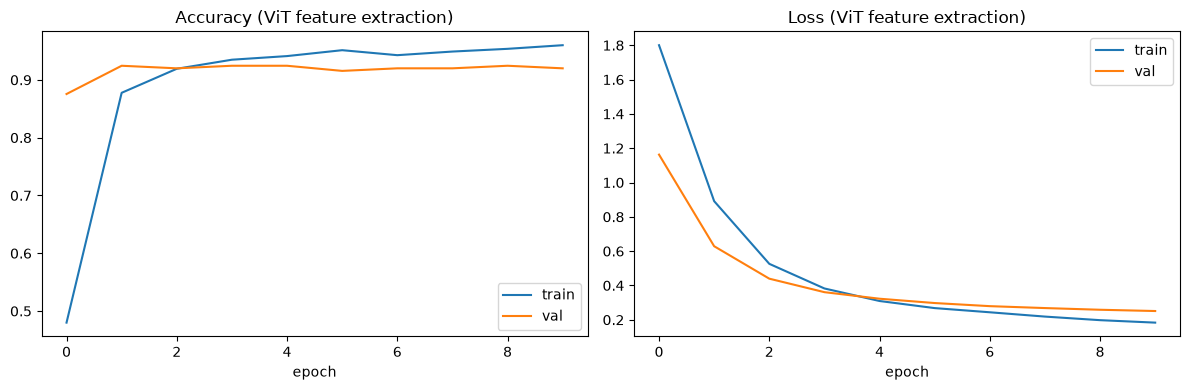

Test accuracy ViT : 0.968


In [14]:
# Tete de classification entrainee sur les features ViT
def build_vit_head():
    model = keras.Sequential([
        layers.Input((F_train.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=ELASTIC_NET),
    ], name="ViT_head")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

vit_head = build_vit_head()
hist_vit = vit_head.fit(F_train, y_train, validation_data=(F_val, y_val),
                        batch_size=BATCH, epochs=60, callbacks=get_callbacks(patience=8), verbose=2)
plot_history(hist_vit, "(ViT feature extraction)")
results['4. ViT (transfer)'] = test_accuracy(vit_head, F_test, y_test)
print("Test accuracy ViT :", round(results['4. ViT (transfer)'], 4))

## Partie 8 - Comparaison finale & analyse d'erreurs

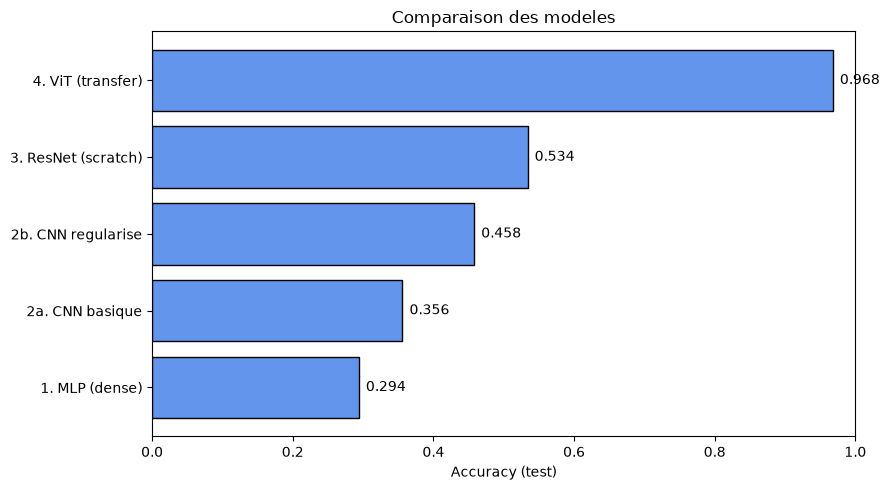

=== Recapitulatif (accuracy test) ===
4. ViT (transfer)         : 0.9680
3. ResNet (scratch)       : 0.5340
2b. CNN regularise        : 0.4580
2a. CNN basique           : 0.3560
1. MLP (dense)            : 0.2940


In [15]:
names = list(results.keys())
accs  = [results[k] for k in names]

plt.figure(figsize=(9, 5))
bars = plt.barh(names, accs, color='cornflowerblue', edgecolor='k')
plt.xlabel("Accuracy (test)"); plt.title("Comparaison des modeles")
for b, a in zip(bars, accs):
    plt.text(a + 0.01, b.get_y() + b.get_height() / 2, f"{a:.3f}", va='center')
plt.xlim(0, 1); plt.tight_layout(); plt.show()

print("=== Recapitulatif (accuracy test) ===")
for k, v in sorted(results.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{k:25s} : {v:.4f}")

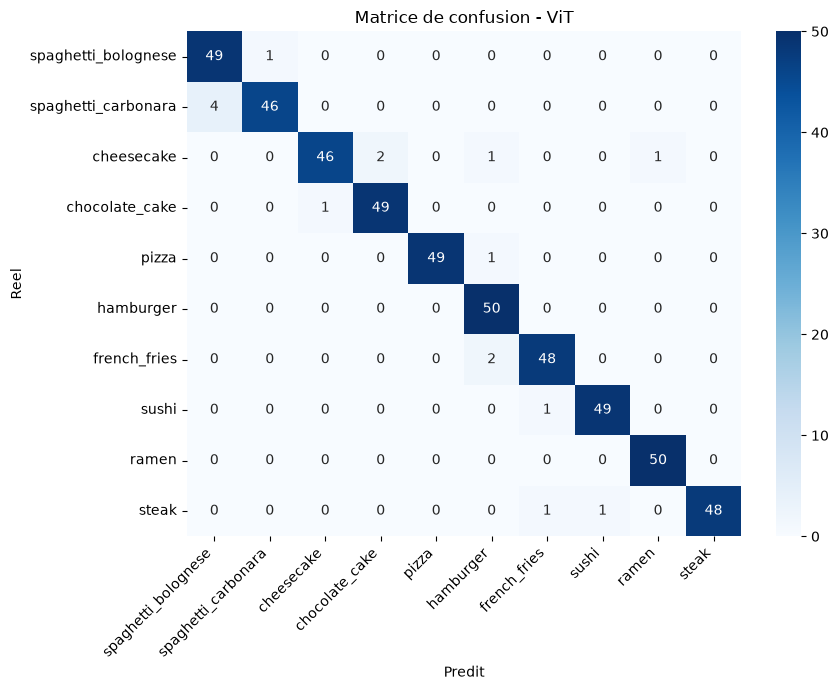

                     precision    recall  f1-score   support

spaghetti_bolognese       0.92      0.98      0.95        50
spaghetti_carbonara       0.98      0.92      0.95        50
         cheesecake       0.98      0.92      0.95        50
     chocolate_cake       0.96      0.98      0.97        50
              pizza       1.00      0.98      0.99        50
          hamburger       0.93      1.00      0.96        50
       french_fries       0.96      0.96      0.96        50
              sushi       0.98      0.98      0.98        50
              ramen       0.98      1.00      0.99        50
              steak       1.00      0.96      0.98        50

           accuracy                           0.97       500
          macro avg       0.97      0.97      0.97       500
       weighted avg       0.97      0.97      0.97       500



In [16]:
# Matrice de confusion du meilleur modele (le ViT)
y_pred = np.argmax(vit_head.predict(F_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SELECTED, yticklabels=SELECTED)
plt.xlabel('Predit'); plt.ylabel('Reel'); plt.title('Matrice de confusion - ViT')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=SELECTED))

## Partie 9 - Conclusion

### Résultats (accuracy de test, 10 classes, 150 images/classe)

| Modèle | Accuracy test |
|--------|:-------------:|
| ViT (transfer learning) | ~0.97 |
| Mini-ResNet (scratch) | ~0.53 |
| CNN B régularisé | ~0.47 |
| CNN A basique | ~0.34 |
| MLP (dense) | ~0.25 |

(les valeurs bougent un peu à chaque run à cause du GPU, mais l'ordre reste le même)

### Ce que j'en retire

Le MLP est le plus faible, et c'est logique : il aplatit l'image et perd toute l'info spatiale. Le CNN basique fait déjà mieux mais il sur-apprend (train ~0.9 alors que la validation plafonne). Le CNN régularisé généralise mieux que le basique grâce à l'augmentation, la BatchNorm, le dropout et l'elastic net. Le ResNet va encore un cran plus loin avec ses skip connections. Et le ViT pré-entraîné écrase tout le monde : ses features apprises sur ImageNet se transfèrent très bien même avec peu d'images.

### Un point qui m'a posé problème

Au début, mon CNN régularisé et mon ResNet sortaient au hasard (~10%), donc en dessous du CNN basique, ce qui n'avait aucun sens. En fait le souci venait de l'entraînement et pas des modèles :
- l'early stopping surveillait `val_loss`, qui remonte tout de suite à cause de la BatchNorm, donc `restore_best_weights` me gardait un modèle pas entraîné. En passant sur `val_accuracy` (avec plus de patience et d'epochs) ça rentre dans l'ordre.
- le MLP divergeait (loss ~15) à cause de l'elastic net sur sa première couche de 25M poids.

Une fois ces deux points corrigés, l'ordre des performances colle avec la théorie.

### Régularisation utilisée
Early stopping, ReduceLROnPlateau, Dropout, BatchNorm, elastic net (L1+L2), data augmentation.

### Analyse d'erreurs
La matrice de confusion du ViT se trompe surtout sur les classes proches : spaghetti bolognese / carbonara et cheesecake / chocolate cake.

### Pistes d'amélioration
Prendre plus d'images par classe (750/250 maintenant que le GPU marche), faire un fine-tuning complet du ViT, tester d'autres backbones, ou du label smoothing.